In [59]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os

(1, 150, 150)


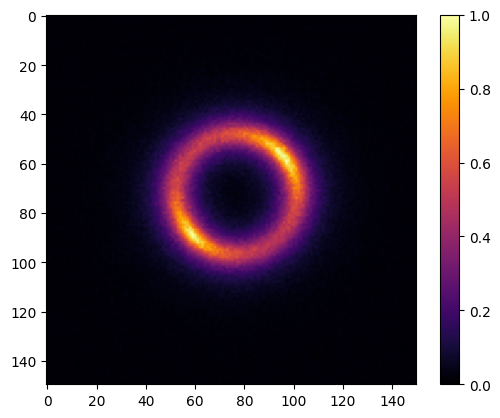

In [92]:
sample_path = "/Users/ishaan/Documents/DeepLense/dataset/train/no"

file = os.listdir(sample_path)[0]

image = np.load(os.path.join(sample_path, file))

print(image.shape)

plt.imshow(image.squeeze(0), cmap="inferno")
plt.colorbar()
plt.show()

In [61]:
class_map = {
    "no": 0,
    "sphere": 1,
    "vort": 2
}

In [75]:
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet18
import torch.fft
from torchvision.transforms import v2

class LensDataset(Dataset):

    def __init__(self, root_dir, transform=None):

        self.samples = []
        self.labels = []
        self.transform = transform
        for cls in class_map.keys():
            folder = os.path.join(root_dir, cls)
            if not os.path.exists(folder): continue
            
            for file in os.listdir(folder):
                if file.endswith(".npy"):
                    path = os.path.join(folder, file)
                    self.samples.append(path)
                    self.labels.append(class_map[cls])

    def __len__(self):
        return len(self.samples)


    def __getitem__(self, idx):
        
        image = np.load(self.samples[idx])
        image_tensor = torch.tensor(image, dtype=torch.float32)
        
        if image_tensor.dim() > 2:
            image_tensor = image_tensor.squeeze()

        image_tensor = image_tensor.unsqueeze(0)

        if self.transform:
            image_tensor = self.transform(image_tensor)

        image_2d = image_tensor.squeeze(0)

        img_min = image_2d.min()
        img_max = image_2d.max()
        image_2d = (image_2d - img_min) / (img_max - img_min + 1e-8)
        fft_complex = torch.fft.fftshift(torch.fft.fft2(image_2d))
        
        fft_magnitude = torch.log(torch.abs(fft_complex) + 1e-8) 
        fft_magnitude = fft_magnitude.unsqueeze(0)
        combined_tensor = torch.cat((image_tensor, fft_magnitude), dim=0)

        label = self.labels[idx]
        return combined_tensor, label

In [76]:
train_transforms = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomChoice([
        v2.RandomRotation((0, 0)),
        v2.RandomRotation((90, 90)),
        v2.RandomRotation((180, 180)),
        v2.RandomRotation((270, 270))
    ])
])

val_transforms = None

In [77]:
from torch.utils.data import DataLoader

train_dataset = LensDataset("/Users/ishaan/Documents/DeepLense/dataset/train")
val_dataset = LensDataset("/Users/ishaan/Documents/DeepLense/dataset/val")

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

In [78]:
import torch.nn as nn
import torchvision.models as models

def get_model():

    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    
    original_weights = model.conv1.weight.clone()

    model.conv1 = nn.Conv2d(
        in_channels=2, 
        out_channels=64,
        kernel_size=7,
        stride=2,
        padding=3,
        bias=False
    )
    
    with torch.no_grad():
        model.conv1.weight[:, 0:1, :, :] = original_weights[:, 0:1, :, :]
        model.conv1.weight[:, 1:2, :, :] = original_weights[:, 1:2, :, :]

    model.fc = nn.Linear(512, 3)

    return model

    return model

In [79]:
model = get_model().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [80]:
epochs = 10

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    print("Epoch:", epoch, "Loss:", total_loss)

Epoch: 0 Loss: 1025.3512742519379
Epoch: 1 Loss: 983.6487517356873
Epoch: 2 Loss: 956.9115245342255
Epoch: 3 Loss: 930.0079690814018
Epoch: 4 Loss: 909.4829089045525
Epoch: 5 Loss: 872.3712965846062
Epoch: 6 Loss: 811.9069790840149
Epoch: 7 Loss: 675.065196454525
Epoch: 8 Loss: 451.72205913066864
Epoch: 9 Loss: 250.14612308889627


In [81]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

In [82]:
model.eval()

all_labels = []
all_probs = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)

        all_probs.append(probs.cpu())
        all_labels.append(labels)

all_probs = torch.cat(all_probs)
all_labels = torch.cat(all_labels)

In [83]:
y_true = all_labels.numpy()
y_score = all_probs.numpy()

y_true_bin = label_binarize(y_true, classes=[0,1,2])

auc = roc_auc_score(y_true_bin, y_score, multi_class="ovr")

print("AUC Score:", auc)

AUC Score: 0.6358673733333333


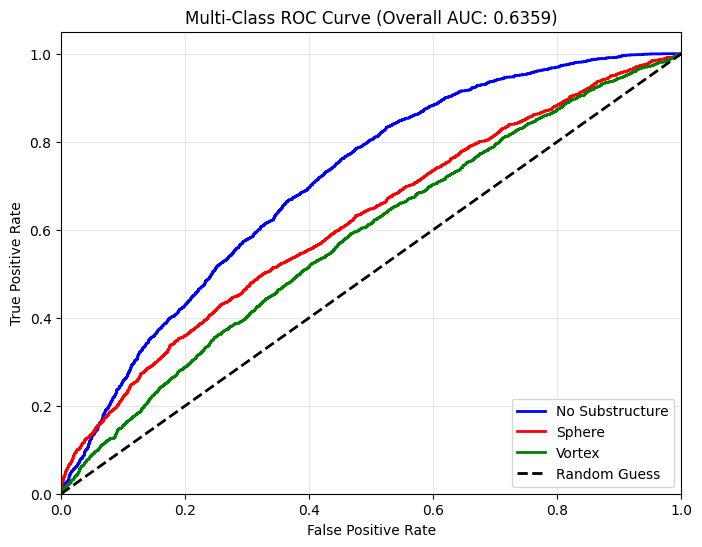

In [84]:
from sklearn.metrics import roc_curve
classes = ['No Substructure', 'Sphere', 'Vortex']
colors = ['blue', 'red', 'green']

plt.figure(figsize=(8, 6))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'{classes[i]}')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'Multi-Class ROC Curve (Overall AUC: {auc:.4f})')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()